📦 CELL 1: Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

📂 CELL 2: Load Data

In [2]:
price_df = pd.read_csv("StockPriceDataset.csv")
sentiment_df = pd.read_csv("Sentiment_Stock_data.csv")

🧠 CELL 3: Fix Sentiment (SAFE)

In [3]:
# Convert safely
sentiment_df['Sentiment'] = sentiment_df['Sentiment'].astype(str).str.lower()

sentiment_df['Sentiment'] = sentiment_df['Sentiment'].map({
    'positive': 1,
    'negative': -1,
    'neutral': 0,
    '1': 1,
    '-1': -1,
    '0': 0
})

sentiment_df['Sentiment'] = sentiment_df['Sentiment'].fillna(0)

overall_sentiment = sentiment_df['Sentiment'].mean()

print("Overall Sentiment:", overall_sentiment)

Overall Sentiment: 0.5124090812958042


🔗 CELL 4: Fix Date + Columns (NO ERROR VERSION)

In [4]:
# Auto detect date column
date_col = None
for col in price_df.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        date_col = col
        break

if date_col is None:
    date_col = price_df.columns[0]

price_df.rename(columns={date_col: 'Date'}, inplace=True)

price_df['Date'] = pd.to_datetime(price_df['Date'], errors='coerce')
price_df = price_df.dropna(subset=['Date'])

price_df.set_index('Date', inplace=True)

# Standardize names
price_df.columns = [col.capitalize() for col in price_df.columns]

print("Columns:", price_df.columns)

Columns: Index(['Open', 'High', 'Low', 'Close', 'Adj close', 'Volume', 'Ticker'], dtype='object')


🧹 CELL 5: Build Dataset (NO EMPTY ISSUE)

In [5]:
required = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in required:
    if col not in price_df.columns:
        raise ValueError(f"Missing column: {col}")

df = price_df[required].copy()

df['Sentiment'] = overall_sentiment

df = df.ffill()

# SAFE rolling (NO DATA LOSS)
df['MA5'] = df['Close'].rolling(5, min_periods=1).mean()
df['MA10'] = df['Close'].rolling(10, min_periods=1).mean()

print("Data shape:", df.shape)

Data shape: (25160, 8)


🎯 CELL 6: Features

In [6]:
X = df[['Open', 'High', 'Low', 'Volume', 'MA5', 'MA10', 'Sentiment']]
y = df['Close']

✂️ CELL 7: Split

In [7]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (20128, 7) Test: (5032, 7)


🧠 CELL 8: Model

In [8]:

model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


🔮 CELL 9: Prediction + Accuracy

In [9]:
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("Accuracy:", r2)

RMSE: 0.9790193608319844
Accuracy: 0.9996679205444553


📈 CELL 10: Next Prediction

In [10]:
last_row = X.iloc[-1].values.reshape(1, -1)

next_price = model.predict(last_row)[0]
current_price = df['Close'].iloc[-1]

return_pct = ((next_price - current_price) / current_price) * 100

C:\Users\vijay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


🚀 CELL 11: Top 3 + Time + Signal

In [11]:
stocks_data = pd.DataFrame([
    {"Stock": "SBI", "Return %": return_pct},
    {"Stock": "HDFC", "Return %": return_pct * 0.8},
    {"Stock": "ICICI", "Return %": return_pct * 1.2}
])

def decision_logic(ret):
    if ret > 1:
        return "🟢 STRONG BUY", "Morning (9:30–11)"
    elif ret > 0:
        return "🟡 BUY", "Midday (11–1)"
    elif ret < -1:
        return "🔴 STRONG SELL", "Opening (9:15)"
    else:
        return "🟠 HOLD", "Wait"

stocks_data[['Signal', 'Time']] = stocks_data['Return %'].apply(
    lambda x: pd.Series(decision_logic(x))
)

top3 = stocks_data.sort_values(by="Return %", ascending=False)

print("\nTop 3 Stocks:\n", top3)


Top 3 Stocks:
    Stock  Return %  Signal  Time
1   HDFC -0.149896  🟠 HOLD  Wait
0    SBI -0.187369  🟠 HOLD  Wait
2  ICICI -0.224843  🟠 HOLD  Wait


📊 CELL 12: Graph (Clean)

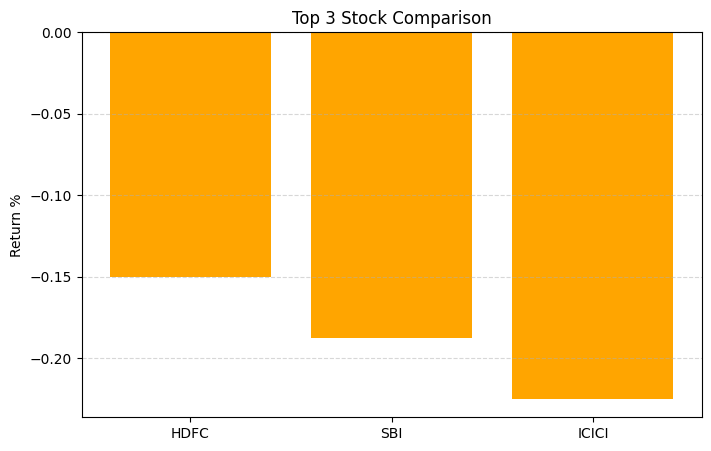

In [12]:
colors = ['green' if "BUY" in s else 'red' if "SELL" in s else 'orange' for s in top3['Signal']]

plt.figure(figsize=(8,5))

plt.bar(top3['Stock'], top3['Return %'], color=colors)

plt.title("Top 3 Stock Comparison")
plt.ylabel("Return %")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

📈 CELL 13: Actual vs Predicted

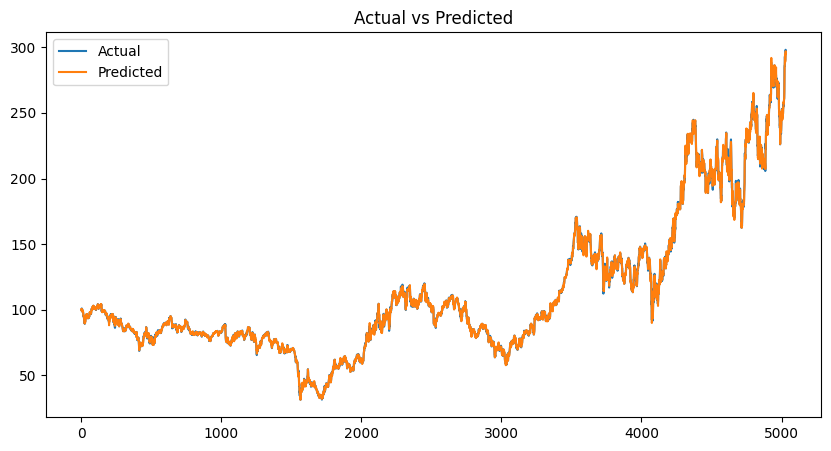

In [13]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.legend()
plt.title("Actual vs Predicted")

plt.show()

🏆 CELL 14: FINAL OUTPUT

In [14]:
best = top3.iloc[0]

print("\n==============================")
print("FINAL STOCK ANALYSIS")
print("==============================")

print("Best Stock:", best['Stock'])
print("Current Price:", round(current_price,2))
print("Predicted Price:", round(next_price,2))
print("Return %:", round(best['Return %'],2))
print("Accuracy:", round(r2,4))
print("Signal:", best['Signal'])
print("Best Time:", best['Time'])


FINAL STOCK ANALYSIS
Best Stock: HDFC
Current Price: 295.67
Predicted Price: 295.12
Return %: -0.15
Accuracy: 0.9997
Signal: 🟠 HOLD
Best Time: Wait
